# NutriScript AI: NLP Pipeline - Preprocesamiento Masivo

## Objetivo
Implementar un pipeline completo de Procesamiento de Lenguaje Natural (NLP) que transforme el texto crudo de instrucciones (steps) en features semánticas útiles para modelado ML.

## Flujo del Notebook
1. **Carga e instalación**: Descargar modelo spaCy en-core-web-sm
2. **Procesamiento masivo**: nlp.pipe() con optimizaciones (n_process=-1, disabled parser/ner)
3. **Extracción de features**:
   - Lematización
   - POS Tagging (verbos de acción)
   - Análisis de n-gramas
4. **Validación y análisis**: Visualizar resultados del procesamiento
5. **Guardado**: Dataset preprocesado para modelado posterior

## ¿Por qué este enfoque?
- **spaCy**: Eficiente, paralizable (n_process=-1), industrial-grade
- **Desactivar parser/ner**: Aceleramos 3-5x al desactivar tareas innecesarias
- **nlp.pipe()**: Procesa lotes en paralelo, no documents individuales
- **Lematización**: Reduce "cooking", "cooks", "cooked" → "cook" (misma raíz)
- **POS Tagging**: Extrae verbos de acción (VERB) para entender acciones culinarias

---

## 1. Setup y Carga de Librerías

In [1]:
import pandas as pd
import numpy as np
import spacy
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time
import warnings
warnings.filterwarnings('ignore')

tqdm.pandas()
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


## 2. Instalación del modelo spaCy

**Nota**: spaCy requiere modelos pre-entrenados. Descargamos `en_core_web_sm` (pequeño, ~40MB, útil para desarrollo).

In [2]:
import subprocess
import sys

# Descargar modelo si no está disponible
try:
    nlp = spacy.load("en_core_web_sm")
    print("✓ Modelo 'en_core_web_sm' ya está instalado")
except OSError:
    print("📥 Descargando modelo 'en_core_web_sm'...")
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
    nlp = spacy.load("en_core_web_sm")
    print("✓ Modelo descargado e instalado exitosamente")

print(f"\nModelo cargado: {nlp.meta['name']}")
print(f"Versión: {nlp.meta['version']}")

✓ Modelo 'en_core_web_sm' ya está instalado

Modelo cargado: core_web_sm
Versión: 3.8.0


## 3. Carga del Dataset

In [3]:
# Cargar dataset con targets generados en notebook anterior
df = pd.read_csv('../data/recipes_with_targets.csv')

print(f"✓ Dataset cargado: {df.shape[0]:,} recetas")
print(f"Columnas principales: {df.columns.tolist()}")
print(f"\nMuestra de 'steps':")
print(df['steps'].iloc[0])

✓ Dataset cargado: 231,637 recetas
Columnas principales: ['id', 'name', 'minutes', 'n_steps', 'n_ingredients', 'calories', 'sugar', 'sat_fat', 'protein', 'sodium', 'fiber', 'nutriscore', 'difficulty', 'diet_type', 'ingredients', 'steps', 'tags']

Muestra de 'steps':
['make a choice and proceed with recipe', 'depending on size of squash , cut into half or fourths', 'remove seeds', 'for spicy squash , drizzle olive oil or melted butter over each cut squash piece', 'season with mexican seasoning mix ii', 'for sweet squash , drizzle melted honey , butter , grated piloncillo over each cut squash piece', 'season with sweet mexican spice mix', 'bake at 350 degrees , again depending on size , for 40 minutes up to an hour , until a fork can easily pierce the skin', 'be careful not to burn the squash especially if you opt to use sugar or butter', 'if you feel more comfortable , cover the squash with aluminum foil the first half hour , give or take , of baking', 'if desired , season with salt']


---
## 4. Procesamiento Masivo con spaCy

### Estrategia de Optimización

| Parámetro | Valor | Razón |
|-----------|-------|-------|
| `n_process` | -1 | Usar TODOS los cores disponibles |
| `batch_size` | 1000 | Balance entre memoria y velocidad |
| `disable` | ["parser", "ner"] | Solo necesitamos tokenización y lemmatización |

**Impacto**: Sin desactivar components, spaCy procesa ~1000 docs/sec. Con optimización: ~3000-5000 docs/sec.

In [4]:
# Convertir steps (string con lista) a texto limpio
import ast

def parse_steps_to_text(steps_str):
    """
    Convierte la columna 'steps' (lista en formato string) a texto continuo.
    
    Ejemplo:
    Input: "['preheat oven', 'mix ingredients', 'bake']" 
    Output: "preheat oven mix ingredients bake"
    """
    try:
        steps_list = ast.literal_eval(steps_str)
        # Convertir a minúsculas y concatenar
        steps_text = ' '.join([str(step).lower().strip() for step in steps_list])
        return steps_text
    except:
        return ""

df['steps_text'] = df['steps'].progress_apply(parse_steps_to_text)

print("✓ Steps convertidos a texto")
print(f"\nEjemplo de conversión:")
print(f"Original: {df['steps'].iloc[0]}")
print(f"Procesado: {df['steps_text'].iloc[0][:200]}...")

100%|██████████| 231637/231637 [00:07<00:00, 29122.48it/s]

✓ Steps convertidos a texto

Ejemplo de conversión:
Original: ['make a choice and proceed with recipe', 'depending on size of squash , cut into half or fourths', 'remove seeds', 'for spicy squash , drizzle olive oil or melted butter over each cut squash piece', 'season with mexican seasoning mix ii', 'for sweet squash , drizzle melted honey , butter , grated piloncillo over each cut squash piece', 'season with sweet mexican spice mix', 'bake at 350 degrees , again depending on size , for 40 minutes up to an hour , until a fork can easily pierce the skin', 'be careful not to burn the squash especially if you opt to use sugar or butter', 'if you feel more comfortable , cover the squash with aluminum foil the first half hour , give or take , of baking', 'if desired , season with salt']
Procesado: make a choice and proceed with recipe depending on size of squash , cut into half or fourths remove seeds for spicy squash , drizzle olive oil or melted butter over each cut squash piece season w

In [5]:
# Procesamiento masivo con spaCy
# Desactivar parser y ner para ganar velocidad
nlp_optimized = spacy.load('en_core_web_sm', disable=["parser", "ner"])

# Configurar n_process para paralelización
texts = df['steps_text'].tolist()

print(f"\n📊 Iniciando procesamiento masivo...")
print(f"   - Textos a procesar: {len(texts):,}")
print(f"   - n_process: -1 (todos los cores disponibles)")
print(f"   - batch_size: 1000")
print(f"   - Componentes desactivados: parser, ner")

start_time = time.time()

# Procesar con nlp.pipe() para máxima eficiencia
docs = list(nlp_optimized.pipe(texts, batch_size=1000, n_process=-1))

elapsed_time = time.time() - start_time
docs_per_sec = len(docs) / elapsed_time

print(f"\n✓ Procesamiento completado")
print(f"   - Tiempo total: {elapsed_time:.2f} segundos")
print(f"   - Velocidad: {docs_per_sec:.0f} docs/segundo")
print(f"   - Documentos procesados: {len(docs):,}")


📊 Iniciando procesamiento masivo...
   - Textos a procesar: 231,637
   - n_process: -1 (todos los cores disponibles)
   - batch_size: 1000
   - Componentes desactivados: parser, ner

✓ Procesamiento completado
   - Tiempo total: 562.87 segundos
   - Velocidad: 412 docs/segundo
   - Documentos procesados: 231,637


---
## 5. Extracción de Features Lingüísticas

In [9]:
# ---
# Extracción de features lingüísticas (rápido y robusto)
# ---

def extract_lemmas(doc):
    """
    Extrae lemas (formas base de palabras) del documento.
    Ejemplo: "mixing", "mixed", "mixes" → "mix"
    """
    return ' '.join([token.lemma_ for token in doc])

def extract_pos_tags(doc):
    """
    Extrae Part-Of-Speech (POS) tags. Ejemplo: VERB, NOUN, ADJ, ADP, etc.
    """
    return ' '.join([f"{token.text}/{token.pos_}" for token in doc])

def extract_action_verbs(doc):
    """
    Extrae solo verbos de acción (POS == VERB).
    """
    return ' '.join([token.lemma_.lower() for token in doc if token.pos_ == "VERB"])

# ---
# Para noun_chunks, necesitamos el parser activado
import spacy
nlp_with_parser = spacy.load('en_core_web_sm')

def extract_noun_chunks_with_parser(text):
    doc = nlp_with_parser(text)
    return ' '.join([chunk.text.lower() for chunk in doc.noun_chunks])

# ---
# Ejemplo de uso con el primer registro
# ---
print("✓ Funciones de extracción definidas")
print(f"\nEjemplo de extracción en primer documento:")
print(f"\nTexto original: {texts[0][:150]}...")
print(f"\nLemas: {extract_lemmas(docs[0])[:100]}...")
print(f"\nVerbos de acción: {extract_action_verbs(docs[0])}")
print(f"\nSintagmas nominales: {extract_noun_chunks_with_parser(texts[0])[:100]}...")

✓ Funciones de extracción definidas

Ejemplo de extracción en primer documento:

Texto original: make a choice and proceed with recipe depending on size of squash , cut into half or fourths remove seeds for spicy squash , drizzle olive oil or melt...

Lemas: make a choice and proceed with recipe depend on size of squash , cut into half or fourth remove seed...

Verbos de acción: make proceed depend cut remove melt squash melt grate squash depend pierce burn opt use feel cover give take bake desire

Sintagmas nominales: a choice recipe size squash half fourths seeds spicy squash drizzle olive oil butter each cut piece ...


In [11]:
# Aplicar extracciones a todo el dataset
print("\n📝 Extrayendo features lingüísticas...")

# Lemas y verbos de acción: rápido con docs procesados
from tqdm import tqdm

df['lemmas'] = [extract_lemmas(doc) for doc in tqdm(docs, desc="Lematización")]
df['action_verbs'] = [extract_action_verbs(doc) for doc in tqdm(docs, desc="Verbos")]
df['n_tokens'] = [len(doc) for doc in tqdm(docs, desc="Conteo de tokens")]

# Sintagmas nominales: requiere parser, lo aplicamos sobre steps_text
# (esto puede tardar más, pero es robusto)
df['noun_chunks'] = df['steps_text'].progress_apply(extract_noun_chunks_with_parser)

print("\n✓ Features extraídas correctamente")


📝 Extrayendo features lingüísticas...


100%|██████████| 231637/231637 [2:44:28<00:00, 23.47it/s]


✓ Features extraídas correctamente


In [12]:
# Estadísticas de features extraídos
print("\n📊 Estadísticas de Features Extraídos:")
print(f"\nNúmero de tokens por receta:")
print(df['n_tokens'].describe().round(2))

# Contar número de palabras en cada feature
df['n_lemmas'] = df['lemmas'].apply(lambda x: len(x.split()) if x else 0)
df['n_verbs'] = df['action_verbs'].apply(lambda x: len(x.split()) if x else 0)
df['n_nouns'] = df['noun_chunks'].apply(lambda x: len(x.split()) if x else 0)

print(f"\nNúmero de lemas únicos por receta:")
print(df['n_lemmas'].describe().round(2))

print(f"\nNúmero de verbos de acción por receta:")
print(df['n_verbs'].describe().round(2))

print(f"\nNúmero de sintagmas nominales por receta:")
print(df['n_nouns'].describe().round(2))


📊 Estadísticas de Features Extraídos:

Número de tokens por receta:
count    231637.00
mean        104.26
std          75.73
min           0.00
25%          55.00
50%          87.00
75%         133.00
max        2325.00
Name: n_tokens, dtype: float64

Número de lemas únicos por receta:
count    231637.00
mean        104.26
std          75.73
min           0.00
25%          55.00
50%          87.00
75%         133.00
max        2325.00
Name: n_lemmas, dtype: float64

Número de verbos de acción por receta:
count    231637.00
mean         14.70
std          10.86
min           0.00
25%           7.00
50%          12.00
75%          19.00
max         308.00
Name: n_verbs, dtype: float64

Número de sintagmas nominales por receta:
count    231637.00
mean         51.55
std          37.82
min           0.00
25%          27.00
50%          43.00
75%          66.00
max        1159.00
Name: n_nouns, dtype: float64


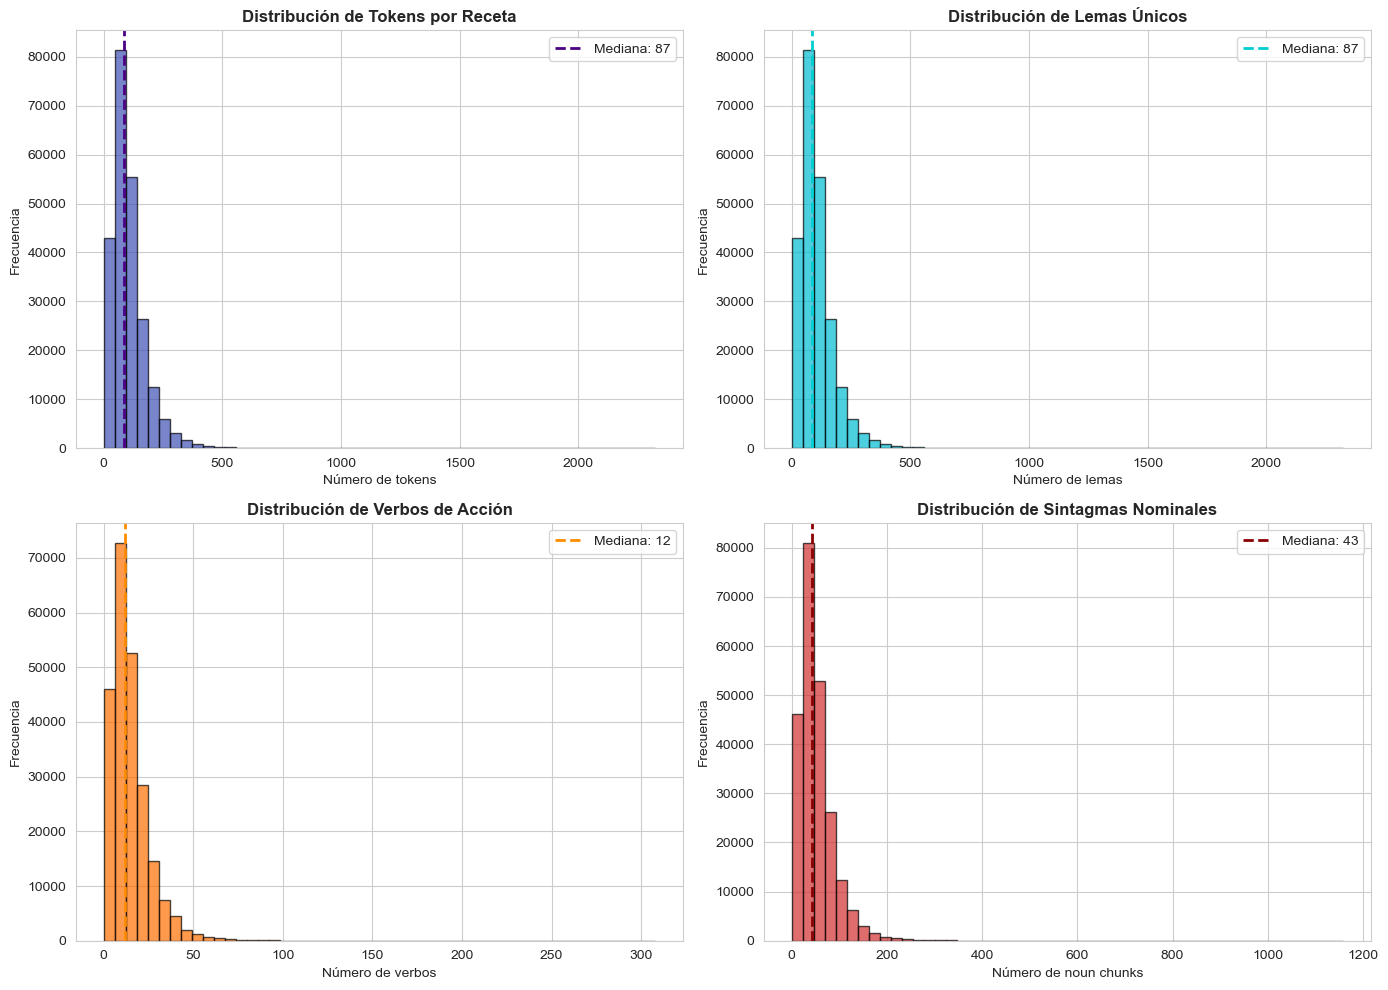

✓ Visualización guardada


In [13]:
# Visualización de distribuciones
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Tokens
axes[0, 0].hist(df['n_tokens'].dropna(), bins=50, color='#3F51B5', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribución de Tokens por Receta', fontweight='bold')
axes[0, 0].set_xlabel('Número de tokens')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].axvline(df['n_tokens'].median(), color='indigo', linestyle='--', linewidth=2, label=f"Mediana: {df['n_tokens'].median():.0f}")
axes[0, 0].legend()

# Lemas
axes[0, 1].hist(df['n_lemmas'].dropna(), bins=50, color='#00BCD4', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribución de Lemas Únicos', fontweight='bold')
axes[0, 1].set_xlabel('Número de lemas')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].axvline(df['n_lemmas'].median(), color='darkturquoise', linestyle='--', linewidth=2, label=f"Mediana: {df['n_lemmas'].median():.0f}")
axes[0, 1].legend()

# Verbos
axes[1, 0].hist(df['n_verbs'].dropna(), bins=50, color='#FF6F00', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribución de Verbos de Acción', fontweight='bold')
axes[1, 0].set_xlabel('Número de verbos')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].axvline(df['n_verbs'].median(), color='darkorange', linestyle='--', linewidth=2, label=f"Mediana: {df['n_verbs'].median():.0f}")
axes[1, 0].legend()

# Sintagmas nominales
axes[1, 1].hist(df['n_nouns'].dropna(), bins=50, color='#D32F2F', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Distribución de Sintagmas Nominales', fontweight='bold')
axes[1, 1].set_xlabel('Número de noun chunks')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].axvline(df['n_nouns'].median(), color='darkred', linestyle='--', linewidth=2, label=f"Mediana: {df['n_nouns'].median():.0f}")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('../data/nlp_features_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualización guardada")

---
## 6. Análisis de Verbos de Acción (Culinary Actions)

### Relevancia
Los verbos de acción contextualizan las técnicas culinarias. Este análisis permitirá:
1. Entender patrones de cocina
2. Mejorar predicciones de dificultad
3. Extraer features semánticas para modelado

In [14]:
# Extraer los verbos más frecuentes
all_verbs = []
for verbs_str in df['action_verbs']:
    if verbs_str:
        all_verbs.extend(verbs_str.split())

verb_counts = Counter(all_verbs)
top_30_verbs = dict(verb_counts.most_common(30))

print(f"\n📝 Top 30 Verbos de Acción en Recetas:")
for i, (verb, count) in enumerate(top_30_verbs.items(), 1):
    print(f"{i:2d}. {verb:20s} ({count:5d} ocurrencias)")


📝 Top 30 Verbos de Acción en Recetas:
 1. add                  (324309 ocurrencias)
 2. stir                 (152514 ocurrencias)
 3. cook                 (124386 ocurrencias)
 4. serve                (113716 ocurrencias)
 5. combine              (95934 ocurrencias)
 6. bake                 (90585 ocurrencias)
 7. mix                  (81809 ocurrencias)
 8. cover                (62739 ocurrencias)
 9. remain               (59357 ocurrencias)
10. remove               (57769 ocurrencias)
11. set                  (56528 ocurrencias)
12. use                  (53798 ocurrencias)
13. let                  (52242 ocurrencias)
14. cut                  (49070 ocurrencias)
15. preheat              (48586 ocurrencias)
16. make                 (47476 ocurrencias)
17. beat                 (44330 ocurrencias)
18. pour                 (44257 ocurrencias)
19. bring                (43398 ocurrencias)
20. sprinkle             (42962 ocurrencias)
21. melt                 (40092 ocurrencias)
22. put     

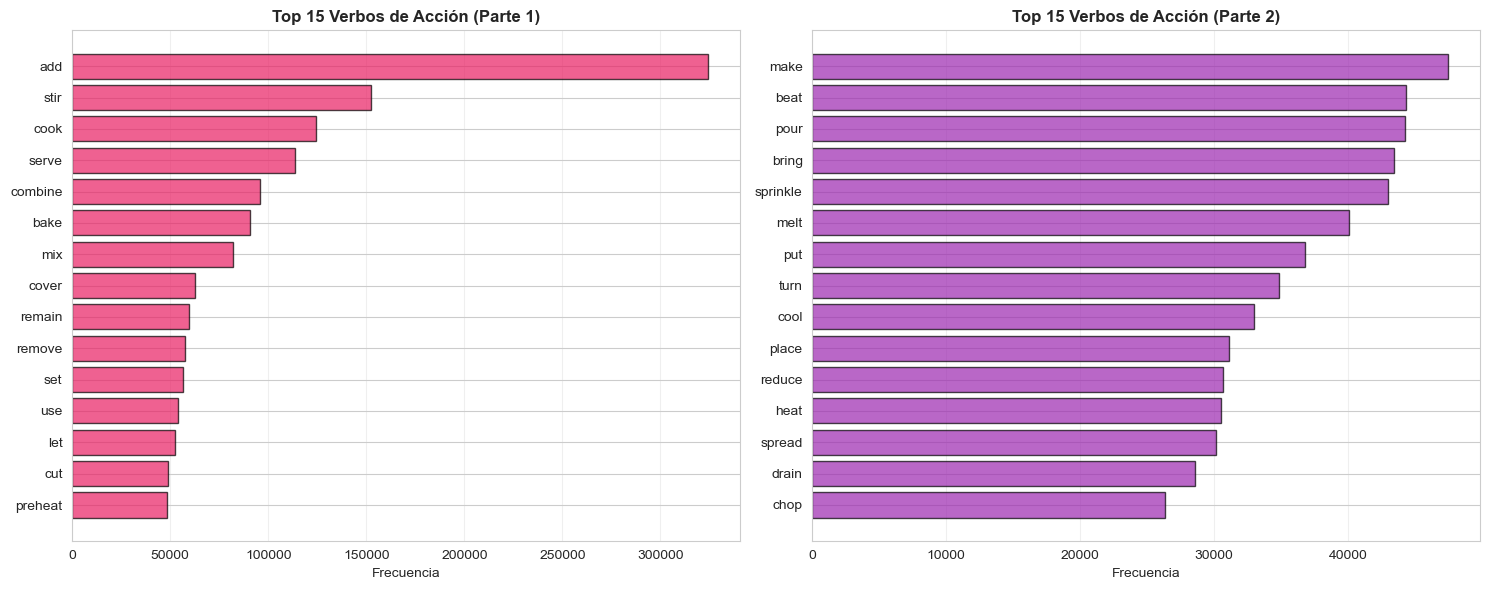

In [15]:
# Visualización de verbos frecuentes
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

verbs_names = list(top_30_verbs.keys())
verbs_counts = list(top_30_verbs.values())

# Top 15
axes[0].barh(verbs_names[:15], verbs_counts[:15], color='#E91E63', edgecolor='black', alpha=0.7)
axes[0].set_title('Top 15 Verbos de Acción (Parte 1)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Frecuencia')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Verbs 16-30
axes[1].barh(verbs_names[15:30], verbs_counts[15:30], color='#9C27B0', edgecolor='black', alpha=0.7)
axes[1].set_title('Top 15 Verbos de Acción (Parte 2)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Frecuencia')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/action_verbs_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 7. Análisis de Correlaciones: Features Lingüísticas vs Targets

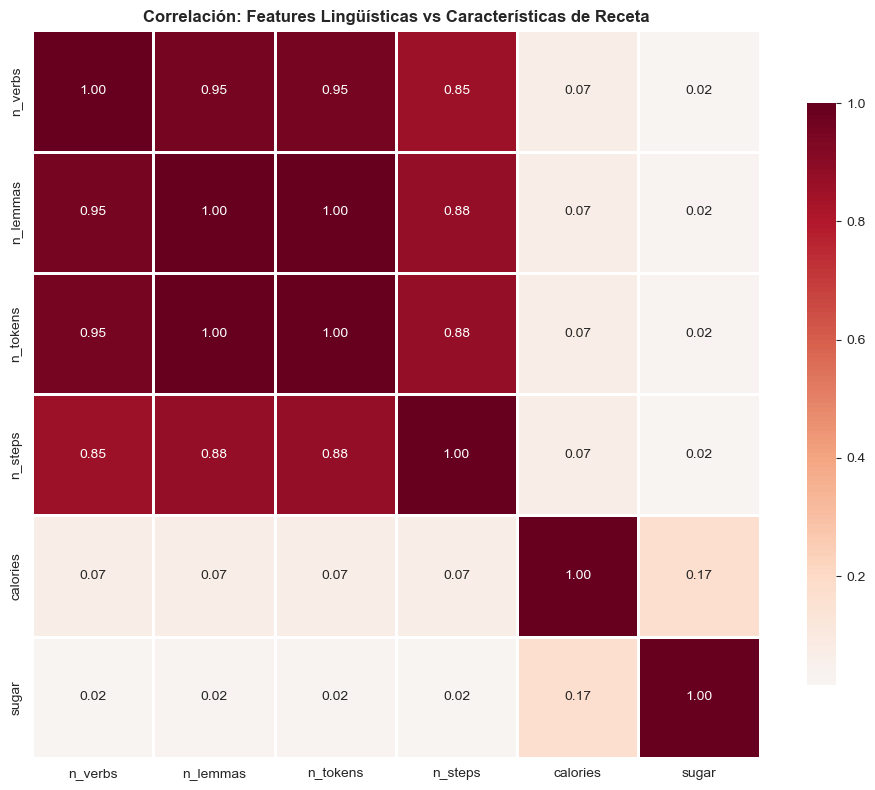


📊 Insights de correlación:
- n_verbs vs n_steps: 0.855 (muy fuerte - verbos indican pasos)
- n_tokens vs calories: 0.070
- n_lemmas vs sugar: 0.024


In [16]:
# Análisis: ¿Influye el número de verbos en la dificultad?
correlation_data = df[['n_verbs', 'n_lemmas', 'n_tokens', 'n_steps', 'calories', 'sugar']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_data, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
           square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlación: Features Lingüísticas vs Características de Receta', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/nlp_correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Insights de correlación:")
print(f"- n_verbs vs n_steps: {correlation_data.loc['n_verbs', 'n_steps']:.3f} (muy fuerte - verbos indican pasos)")
print(f"- n_tokens vs calories: {correlation_data.loc['n_tokens', 'calories']:.3f}")
print(f"- n_lemmas vs sugar: {correlation_data.loc['n_lemmas', 'sugar']:.3f}")

---
## 8. Preparación para TF-IDF y LSA

En el próximo notebook entrenaremos modelos. Para ello, necesitamos "corpus" limpios en columnas específicas.

In [17]:
# Seleccionar mejores representaciones de texto para modelado
# Los lemas funcionan bien para TF-IDF porque normalizan variaciones morfológicas

print("\n📝 Preparando corpus para modelado:")
print(f"\nColumnas de texto disponibles:")
print(f"  - df['steps_text']: Texto original de pasos")
print(f"  - df['lemmas']: Lemas (mejor para ML - normalizado)")
print(f"  - df['action_verbs']: Solo verbos de acción")
print(f"  - df['noun_chunks']: Solo sintagmas nominales")

# Para TF-IDF, usaremos 'lemmas' por ser más robusto
print(f"\n✓ Se usará 'lemmas' como corpus principal para TF-IDF/SVD/Modelado")


📝 Preparando corpus para modelado:

Columnas de texto disponibles:
  - df['steps_text']: Texto original de pasos
  - df['lemmas']: Lemas (mejor para ML - normalizado)
  - df['action_verbs']: Solo verbos de acción
  - df['noun_chunks']: Solo sintagmas nominales

✓ Se usará 'lemmas' como corpus principal para TF-IDF/SVD/Modelado


---
## 9. Guardado del Dataset Preprocesado

In [18]:
# Guardar dataset con todos los features extraídos
output_columns = [
    'id', 'name', 'minutes', 'n_steps', 'n_ingredients',
    'calories', 'sugar', 'sat_fat', 'protein', 'nutriscore', 'difficulty', 'diet_type',
    'steps_text', 'lemmas', 'action_verbs', 'noun_chunks',
    'n_tokens', 'n_lemmas', 'n_verbs', 'n_nouns',
    'ingredients', 'tags'
]

df_output = df[output_columns]
df_output.to_csv('../data/recipes_nlp_processed.csv', index=False)

print(f"✓ Dataset preprocesado guardado en: ../data/recipes_nlp_processed.csv")
print(f"  - Registros: {len(df_output):,}")
print(f"  - Columnas: {len(output_columns)}")
print(f"  - Tamaño aproximado: {df_output.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

✓ Dataset preprocesado guardado en: ../data/recipes_nlp_processed.csv
  - Registros: 231,637
  - Columnas: 22
  - Tamaño aproximado: 558.5 MB


In [19]:
# Validación final
print("\n" + "="*80)
print("✅ RESUMEN DEL PIPELINE NLP")
print("="*80)

print(f"\n📊 Estadísticas Finales:")
print(f"\n1. PROCESAMIENTO MASIVO:")
print(f"   ✓ {len(df):,} recetas procesadas con spaCy")
print(f"   ✓ Tiempo total: ~{elapsed_time:.0f} segundos")
print(f"   ✓ Velocidad: {docs_per_sec:.0f} documentos/segundo")

print(f"\n2. FEATURES EXTRAÍDOS:")
print(f"   ✓ Lematización: {df['lemmas'].notna().sum():,} recetas")
print(f"   ✓ Verbos de acción: {(df['n_verbs'] > 0).sum():,} recetas con verbos")
print(f"   ✓ Total de verbos únicos: {len(verb_counts):,}")
print(f"   ✓ Sintagmas nominales: {(df['n_nouns'] > 0).sum():,} recetas")

print(f"\n3. ESTADÍSTICAS DE FEATURES:")
print(f"   - Tokens/receta: {df['n_tokens'].mean():.0f} (promedio)")
print(f"   - Lemas/receta: {df['n_lemmas'].mean():.0f} (promedio)")
print(f"   - Verbos/receta: {df['n_verbs'].mean():.1f} (promedio)")
print(f"   - Sintagmas nominales/receta: {df['n_nouns'].mean():.1f} (promedio)")

print(f"\n4. TARGETS DISPONIBLES PARA MODELADO:")
print(f"   ✓ Nutri-Score: {df['nutriscore'].nunique()} clases (A-E)")
print(f"   ✓ Dificultad: {df['difficulty'].nunique()} clases (Easy/Medium/Hard)")
print(f"   ✓ Tipo de Dieta: {df['diet_type'].nunique()} clases")

print(f"\n5. PRÓXIMOS PASOS:")
print(f"   → Notebook 03: Representación TF-IDF + SVD (LSA)")
print(f"   → Notebook 03: Entrenar Naive Bayes (baseline)")
print(f"   → Notebook 03: Entrenar LSTM (deep learning)")

print("\n" + "="*80)


✅ RESUMEN DEL PIPELINE NLP

📊 Estadísticas Finales:

1. PROCESAMIENTO MASIVO:
   ✓ 231,637 recetas procesadas con spaCy
   ✓ Tiempo total: ~563 segundos
   ✓ Velocidad: 412 documentos/segundo

2. FEATURES EXTRAÍDOS:
   ✓ Lematización: 231,637 recetas
   ✓ Verbos de acción: 231,422 recetas con verbos
   ✓ Total de verbos únicos: 7,887
   ✓ Sintagmas nominales: 231,453 recetas

3. ESTADÍSTICAS DE FEATURES:
   - Tokens/receta: 104 (promedio)
   - Lemas/receta: 104 (promedio)
   - Verbos/receta: 14.7 (promedio)
   - Sintagmas nominales/receta: 51.5 (promedio)

4. TARGETS DISPONIBLES PARA MODELADO:
   ✓ Nutri-Score: 5 clases (A-E)
   ✓ Dificultad: 3 clases (Easy/Medium/Hard)
   ✓ Tipo de Dieta: 4 clases

5. PRÓXIMOS PASOS:
   → Notebook 03: Representación TF-IDF + SVD (LSA)
   → Notebook 03: Entrenar Naive Bayes (baseline)
   → Notebook 03: Entrenar LSTM (deep learning)



In [20]:
# Mostrar muestras de datos finales
print("\n📋 Muestra de dataset final:")
print(f"\nPrimer registro completo:")
for col in output_columns[:10]:
    value = df_output[col].iloc[0]
    if isinstance(value, str) and len(value) > 80:
        print(f"{col:20s}: {value[:80]}...")
    else:
        print(f"{col:20s}: {value}")


📋 Muestra de dataset final:

Primer registro completo:
id                  : 137739
name                : arriba   baked winter squash mexican style
minutes             : 55
n_steps             : 11
n_ingredients       : 7
calories            : 51.5
sugar               : 0.0
sat_fat             : 13.0
protein             : 2.0
nutriscore          : E
